# 흉부 X-ray 폐렴 진단 모델 변환 #2 : ONNX 추론 및 3종 비교 평가

과제식별: [스프린트 미션16](https://www.codeit.kr/topics/studyGroupStep6985c0c3b71ad43b08e455fa/lessons/14112)  
작성: 2026.07.15 신호정

## G. ONNX 기반 추론 파이프라인

### G-a. 계획 확인

- 추론 요건: onnxruntime 세션으로 ONNX 모델을 로드하고 test set 624장을 평가합니다.
- 전처리 일치: `modeling.ipynb`의 전처리(CLAHE → 패딩 → 리사이즈 → 3채널 → ImageNet 정규화)를  
  **numpy 기준으로 재구현**하고, 동일 샘플로 torchvision 파이프라인과의 일치를 검증합니다.
  (ONNX 경로가 torch 전처리에 의존하지 않음을 보이기 위함)
- 포멧 별 로드 경로:
  | 포맷 | 로드 방식 |
  |---|---|
  | FP32 `.pth` | 모델 구조 재구성 + `state_dict` 로드 |
  | INT8 `.pth` | `torch.jit.load` (TorchScript : 구조 재구성 불필요) |
  | ONNX | `onnxruntime.InferenceSession` |
- ONNX는 Fixed Shape `(1, 3, 224, 224)`이므로 한 번에 이미지 1장씩 루프처리합니다.  
  반면에 Pytorch로 로드하는 pth 포멧인 FP32/INT8은 배치 평가합니다. (예측 결과는 배치 크기와 무관)
- 지표 평가는 CPU에서 수행합니다 (INT8은 CPU 전용이라 3종 동일 조건으로 수행하기 위함)

### G-b. 환경 설정

#### G-b-1. 공용 패키지 임포트

In [1]:
import logging
import sys
import time
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torchvision

# onnxruntime GPU 빌드는 libcudart.so.12를 요구하므로 torch를 먼저 import하여
# torch 동봉 CUDA 런타임이 프로세스에 로드된 뒤에 import한다
import onnx
import onnxruntime as ort
from matplotlib import font_manager
from PIL import Image
from sklearn.metrics import confusion_matrix

print(f"python      : {sys.version.split()[0]}")
print(f"torch       : {torch.__version__}")
print(f"torchvision : {torchvision.__version__}")
print(f"onnx        : {onnx.__version__}")
print(f"onnxruntime : {ort.__version__}")
print(f"opencv      : {cv2.__version__}")

python      : 3.12.13
torch       : 2.10.0+cu128
torchvision : 0.25.0+cu128
onnx        : 1.21.0
onnxruntime : 1.27.1
opencv      : 4.13.0


#### G-b-2. 로깅 및 그래프 한글 폰트 설정

In [2]:
logging.basicConfig(
    level=logging.INFO,
    format="[%(asctime)s] [%(levelname)s] %(message)s",
    datefmt="%H:%M:%S",
    stream=sys.stdout,
    force=True,
)
logger = logging.getLogger("mission16")


def register_korean_font() -> None:
    """NanumGothic 폰트를 matplotlib에 등록한다. 없으면 기본 폰트로 진행한다."""
    for font_path in (Path("../NanumGothic.ttf"), Path("NanumGothic.ttf")):
        if font_path.exists():
            font_manager.fontManager.addfont(str(font_path))
            plt.rcParams["font.family"] = "NanumGothic"
            plt.rcParams["axes.unicode_minus"] = False
            logger.info(f"한글 폰트 등록: {font_path}")
            return
    logger.warning("NanumGothic.ttf 미발견 — 기본 폰트로 진행 (한글 라벨이 깨질 수 있음)")


register_korean_font()

[17:09:15] [INFO] 한글 폰트 등록: ../NanumGothic.ttf


#### G-b-3. 시드·경로 상수 관리 (Colab 분기 포함)

In [ ]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

try:
    import google.colab
    is_colab = True
except ImportError:
    is_colab = False

CLASS_NAMES = ("NORMAL", "PNEUMONIA")
NUM_CLASSES = len(CLASS_NAMES)

LOCAL_DATA_ROOT = Path("/mnt/wsl_data/datasets/chest-xray-pneumonia/chest-x-ray-images-pneumonia")


def resolve_data_root() -> Path:
    """데이터 루트를 결정한다. 로컬 절대경로 기본, Colab에서는 kagglehub 캐시를 사용한다."""
    if not is_colab:
        return LOCAL_DATA_ROOT

    import kagglehub

    downloaded = Path(kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia"))
    for train_dir in downloaded.rglob("train"):
        if (train_dir.parent / "test").exists():
            return train_dir.parent
    raise FileNotFoundError(f"kagglehub 경로에서 train/test 구조를 찾지 못했습니다: {downloaded}")


TEST_DIR = resolve_data_root() / "test"
if not TEST_DIR.exists():
    TEST_DIR.mkdir(exist_ok=True)

MODELS_DIR = Path("models")
FP32_PATH = MODELS_DIR / "mission_16_mobilenetv3.pth"
INT8_PATH = MODELS_DIR / "mission_16_mobilenetv3_quant.pth"
ONNX_PATH = MODELS_DIR / "mission_16_mobilenetv3.onnx"

if not MODELS_DIR.exists():
    MODELS_DIR.mkdir(exist_ok=True)

logger.info(f"TEST_DIR: {TEST_DIR}")
logger.info("모델 3종 파일 확인 완료")

[17:09:15] [INFO] TEST_DIR: /mnt/wsl_data/datasets/chest-xray-pneumonia/chest-x-ray-images-pneumonia/test


[17:09:15] [INFO] 모델 3종 파일 확인 완료


### G-c. 전처리 numpy 재구현

#### G-c-1. 전처리 함수 구현

`modeling.ipynb`의 전처리를 numpy, cv2 기반으로 아래와 같이 재구현합니다.
- CLAHE(clip 2.0, tile 8×8)
- 가로세로비 유지 패딩
- 224×224 리사이즈
- 3채널 복제
- 0 ~ 1 스케일
- ImageNet 정규화
- `(3, 224, 224)` float32.

In [4]:
IMAGE_SIZE = 224
IMAGENET_MEAN = np.array((0.485, 0.456, 0.406), dtype=np.float32).reshape(3, 1, 1)
IMAGENET_STD = np.array((0.229, 0.224, 0.225), dtype=np.float32).reshape(3, 1, 1)
CLAHE_CLIP_LIMIT = 2.0
CLAHE_TILE_GRID = (8, 8)

clahe = cv2.createCLAHE(clipLimit=CLAHE_CLIP_LIMIT, tileGridSize=CLAHE_TILE_GRID)


def pad_to_square(img: np.ndarray) -> np.ndarray:
    """가로세로비를 유지한 채 검은색 패딩으로 정방형 이미지를 만든다."""
    h, w = img.shape[:2]
    if h == w:
        return img

    max_side = max(h, w)
    padded = np.zeros((max_side, max_side), dtype=img.dtype)
    y_offset = (max_side - h) // 2
    x_offset = (max_side - w) // 2
    padded[y_offset:y_offset + h, x_offset:x_offset + w] = img
    return padded


def preprocess_image(path: Path) -> np.ndarray:
    """X-ray 1장을 모델 입력 (3, 224, 224) float32로 변환한다 (modeling과 동일 파이프라인)."""
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"이미지 로드 실패: {path}")

    img = clahe.apply(img)
    img = pad_to_square(img)
    img = cv2.resize(img, (IMAGE_SIZE, IMAGE_SIZE), interpolation=cv2.INTER_AREA)

    arr = img.astype(np.float32) / 255.0
    arr = np.stack([arr, arr, arr], axis=0)
    return (arr - IMAGENET_MEAN) / IMAGENET_STD


logger.info("numpy 전처리 함수 준비 완료")

[17:09:15] [INFO] numpy 전처리 함수 준비 완료


#### G-c-2. modeling 전처리와의 일치 검증

동일 샘플 1장을 numpy 파이프라인과  
torchvision 파이프라인(modeling 방식)으로  
각각 처리하여 **`두 코드가 같은 계산을 하는지`** 확인합니다.

In [ ]:
from torchvision import transforms

sample_path = sorted((TEST_DIR / "NORMAL").glob("*.jpeg"))[0]

np_out = preprocess_image(sample_path)

# modeling.ipynb과 동일한 torchvision 경로 (참조 구현)
ref_img = cv2.imread(str(sample_path), cv2.IMREAD_GRAYSCALE)
ref_img = clahe.apply(ref_img)
ref_img = pad_to_square(ref_img)
ref_img = cv2.resize(ref_img, (IMAGE_SIZE, IMAGE_SIZE), interpolation=cv2.INTER_AREA)
pil_img = Image.fromarray(ref_img).convert("RGB")
ref_tensor = transforms.Normalize(IMAGENET_MEAN.flatten(), IMAGENET_STD.flatten())(
    transforms.ToTensor()(pil_img)
)
ref_out = ref_tensor.numpy()

max_diff = np.abs(np_out - ref_out).max()
print(f"샘플: {sample_path.name}")
print(f"numpy 전처리 shape: {np_out.shape}, dtype: {np_out.dtype}")
print(f"torchvision 대비 최대 오차: {max_diff:.2e}")
assert np_out.shape == (3, IMAGE_SIZE, IMAGE_SIZE)
assert max_diff < 1e-6, "전처리 결과가 modeling 파이프라인과 일치하지 않습니다." # 백만분의 1 미만 오차까지 허용, 사실상 동일
print("전처리 일치 검증 통과")

샘플: IM-0001-0001.jpeg
numpy 전처리 shape: (3, 224, 224), dtype: float32
torchvision 대비 최대 오차: 0.00e+00
전처리 일치 검증 통과


### G-d. 테스트 데이터 준비

test 624장을 수집하고 전처리를 일괄 적용해 배열로 보관합니다.  
(3종 모델이 동일한 입력을 사용하도록 전처리는 1회만 수행)

In [ ]:
def collect_test_set(test_dir: Path) -> tuple[list[Path], np.ndarray]:
    """test 디렉터리에서 이미지 경로와 라벨을 수집한다."""
    paths: list[Path] = []
    labels: list[int] = []
    for cls_idx, cls_name in enumerate(CLASS_NAMES):
        cls_dir = test_dir / cls_name
        for ext in ("*.jpeg", "*.jpg", "*.png"):
            for p in sorted(cls_dir.glob(ext)):
                if p.name.startswith("._"): # 메타파일 필터링
                    continue
                paths.append(p)
                labels.append(cls_idx)
    return paths, np.array(labels)


test_paths, y_true = collect_test_set(TEST_DIR)
logger.info(f"test: {len(test_paths)}장 (NORMAL {int((y_true == 0).sum())} / PNEUMONIA {int((y_true == 1).sum())})")
assert len(test_paths) == 624, "test 매수가 624장이 아닙니다."

start = time.perf_counter()
X_test = np.stack([preprocess_image(p) for p in test_paths]).astype(np.float32)
logger.info(f"전처리 완료: X_test {X_test.shape} ({time.perf_counter() - start:.1f}s)")

[17:09:15] [INFO] test: 624장 (NORMAL 234 / PNEUMONIA 390)


[17:09:21] [INFO] 전처리 완료: X_test (624, 3, 224, 224) (6.1s)


### G-e. 3종 모델 로더

#### G-e-1. FP32 : 구조 재구성 + state_dict 로드

In [ ]:
from torchvision.models.quantization import mobilenet_v3_large


def build_model(num_classes: int = NUM_CLASSES) -> nn.Module:
    """modeling.ipynb과 동일한 구조를 재구성한다 (양자화 대응 MobileNetV3-Large)."""
    model = mobilenet_v3_large(weights=None, quantize=False)
    in_features = model.classifier[3].in_features
    model.classifier[3] = nn.Linear(in_features, num_classes)
    return model


fp32_model = build_model()
fp32_model.load_state_dict(torch.load(FP32_PATH, map_location="cpu"))
fp32_model.eval()
logger.info(f"FP32 로드 완료: {FP32_PATH} ({FP32_PATH.stat().st_size / (1024 * 1024):.2f} MB)")

[17:09:21] [INFO] FP32 로드 완료: models/mission_16_mobilenetv3.pth (16.24 MB)


#### G-e-2. INT8 : TorchScript 로드 (구조 재구성 불필요)

In [ ]:
int8_model = torch.jit.load(str(INT8_PATH), map_location="cpu")
int8_model.eval()
logger.info(f"INT8 로드 완료: {INT8_PATH} ({INT8_PATH.stat().st_size / (1024 * 1024):.2f} MB)")

[17:09:21] [INFO] INT8 로드 완료: models/mission_16_mobilenetv3_quant.pth (4.47 MB)


#### G-e-3. ONNX : onnxruntime 세션

In [ ]:
ort_session = ort.InferenceSession(str(ONNX_PATH), providers=["CPUExecutionProvider"])
onnx_input_name = ort_session.get_inputs()[0].name
onnx_input_shape = ort_session.get_inputs()[0].shape
logger.info(
    f"ONNX 세션 준비 완료: {ONNX_PATH} ({ONNX_PATH.stat().st_size / (1024 * 1024):.2f} MB), "
    f"입력 '{onnx_input_name}' {onnx_input_shape}"
)
assert onnx_input_shape == [1, 3, IMAGE_SIZE, IMAGE_SIZE], "Fixed Shape (1,3,224,224)가 아닙니다."

[17:09:21] [INFO] ONNX 세션 준비 완료: models/mission_16_mobilenetv3.onnx (16.03 MB), 입력 'input' [1, 3, 224, 224]


### G-f. 공통 예측 및 평가 함수

3종 모델을 동일 인터페이스(`(N, 3, 224, 224) float32 → (N,) 라벨`)로 감싸고,  
지표 계산(accuracy / Recall(폐렴) / FN / 혼동행렬)과 시각화 함수를 정의합니다.

In [10]:
EVAL_BATCH_SIZE = 64


@torch.no_grad()
def predict_torch(model: nn.Module, x: np.ndarray) -> np.ndarray:
    """PyTorch 모델(FP32/INT8)로 배치 예측 라벨을 반환한다."""
    preds = []
    for start in range(0, len(x), EVAL_BATCH_SIZE):
        xb = torch.from_numpy(x[start:start + EVAL_BATCH_SIZE])
        preds.append(model(xb).argmax(dim=1).numpy())
    return np.concatenate(preds)


def predict_onnx(session: ort.InferenceSession, x: np.ndarray) -> np.ndarray:
    """ONNX 세션으로 예측 라벨을 반환한다 (Fixed Shape이므로 단건 루프)."""
    preds = np.empty(len(x), dtype=np.int64)
    for i in range(len(x)):
        logits = session.run(None, {onnx_input_name: x[i:i + 1]})[0]
        preds[i] = int(logits.argmax())
    return preds


def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    """accuracy / Recall(폐렴) / FN / 혼동행렬을 계산한다."""
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    return {
        "accuracy": float((tn + tp) / cm.sum()),
        "recall": float(tp / (tp + fn)) if (tp + fn) > 0 else 0.0,
        "fn": int(fn),
        "cm": cm,
    }


def plot_confusion_matrix(cm: np.ndarray, title: str, ax=None) -> None:
    """혼동행렬을 히트맵으로 그린다. FN 칸(폐렴→정상 오판)은 강조 표기한다."""
    if ax is None:
        _, ax = plt.subplots(figsize=(4.5, 4))
    ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(NUM_CLASSES), CLASS_NAMES)
    ax.set_yticks(range(NUM_CLASSES), CLASS_NAMES)
    ax.set_xlabel("예측")
    ax.set_ylabel("실제")
    ax.set_title(title)
    threshold = cm.max() / 2
    for row in range(NUM_CLASSES):
        for col in range(NUM_CLASSES):
            note = " (FN)" if (row == 1 and col == 0) else ""
            ax.text(
                col, row, f"{cm[row, col]}{note}",
                ha="center", va="center",
                color="white" if cm[row, col] > threshold else "black",
            )


logger.info("공통 예측·평가 함수 준비 완료")

[17:09:21] [INFO] 공통 예측·평가 함수 준비 완료


### G-g. 단건 추론 상호 비교

동일 이미지(클래스별 1장)에 대해 3종 모델의 logits과 예측 라벨을 비교합니다.  
FP32와 ONNX는 동일 가중치의 수치 등가 변환이므로 라벨이 일치해야 하고,  
INT8은 양자화 오차로 달라질 수 있어 일치 여부를 관찰합니다.

In [11]:
sample_indices = [0, len(test_paths) - 1]

for idx in sample_indices:
    x1 = X_test[idx:idx + 1]
    with torch.no_grad():
        logits_fp32 = fp32_model(torch.from_numpy(x1)).numpy()[0]
        logits_int8 = int8_model(torch.from_numpy(x1)).numpy()[0]
    logits_onnx = ort_session.run(None, {onnx_input_name: x1})[0][0]

    labels = {
        "FP32": int(logits_fp32.argmax()),
        "INT8": int(logits_int8.argmax()),
        "ONNX": int(logits_onnx.argmax()),
    }
    print(f"[{test_paths[idx].name}] 실제: {CLASS_NAMES[y_true[idx]]}")
    print(f"  FP32 logits {np.round(logits_fp32, 4)} → {CLASS_NAMES[labels['FP32']]}")
    print(f"  INT8 logits {np.round(logits_int8, 4)} → {CLASS_NAMES[labels['INT8']]}")
    print(f"  ONNX logits {np.round(logits_onnx, 4)} → {CLASS_NAMES[labels['ONNX']]}")
    print(f"  라벨 일치: FP32-ONNX {'O' if labels['FP32'] == labels['ONNX'] else 'X'}, "
          f"FP32-INT8 {'O' if labels['FP32'] == labels['INT8'] else 'X'}")
    print()

    assert labels["FP32"] == labels["ONNX"], "FP32와 ONNX 라벨이 불일치합니다."

print("단건 추론 상호 비교 완료 — 추론 파이프라인 정상 작동")

[IM-0001-0001.jpeg] 실제: NORMAL
  FP32 logits [-2.6278  1.8551] → PNEUMONIA
  INT8 logits [-2.7899  2.3249] → PNEUMONIA
  ONNX logits [-2.6278  1.8551] → PNEUMONIA
  라벨 일치: FP32-ONNX O, FP32-INT8 O

[person99_bacteria_474.jpeg] 실제: PNEUMONIA
  FP32 logits [-5.0339  4.309 ] → PNEUMONIA
  INT8 logits [-5.0217  4.2778] → PNEUMONIA
  ONNX logits [-5.0339  4.309 ] → PNEUMONIA
  라벨 일치: FP32-ONNX O, FP32-INT8 O

단건 추론 상호 비교 완료 — 추론 파이프라인 정상 작동


### G-h. 추론 파이프라인 정리

- numpy 재구현 전처리가 torchvision 파이프라인과 **최대 오차 0.00으로 완전 일치** 합니다.  
  uint8 단계까지 결정적 연산(cv2)이 동일하고 이후 스케일과 정규화가 같은 float32 연산이기 때문입니다.
- 3종 로더 정상 작동: FP32(구조 재구성), INT8(TorchScript 단일 파일), ONNX(ort 세션, Fixed Shape 확인).
- 단건 상호 비교: FP32와 ONNX는 **logits 수준까지 동일**,  
  INT8은 logits이 소폭 다르나 관찰 샘플에서 라벨 일치합니다.  
  따라서 추론 파이프라인 정상 작동을 확인할 수 있습니다.

## H. 3종 포맷 비교 평가

### H-a. 계획 확인

- 비교 항목: **파일 용량 / test accuracy / Recall(폐렴) / FN 개수 / CPU 추론 지연시간**.
- 지표 평가(H-b): 3종 모두 동일한 전처리 배열(`X_test`)로 test 624장 전체를 예측합니다.  
  (예측 라벨은 스레드 수와 배치 크기와 무관하므로 평가 속도를 위해 배치와 멀티스레드 사용)
- 지연시간 측정(H-c): **단일 이미지 `(1, 3, 224, 224)`, 단일 스레드 고정**  
  `torch.set_num_threads(1)`, ort 세션 `intra_op / inter_op = 1`로 3종 동일 조건을 맞춥니다.  
  warmup 10회 후 50회 평균 ± 표준편차. 전처리 시간은 제외하고 순수 모델 추론만 측정합니다.  
  (온디바이스 단건 추론 시나리오를 모사 : 엣지 기기는 대부분 소수 코어와 단건 요청입니다)

### H-b. test 624장 전체 평가

In [12]:
start = time.perf_counter()
pred_fp32 = predict_torch(fp32_model, X_test)
pred_int8 = predict_torch(int8_model, X_test)
pred_onnx = predict_onnx(ort_session, X_test)
logger.info(f"3종 전체 예측 완료 ({time.perf_counter() - start:.1f}s)")

results = {
    "FP32": compute_metrics(y_true, pred_fp32),
    "INT8": compute_metrics(y_true, pred_int8),
    "ONNX": compute_metrics(y_true, pred_onnx),
}

agree_onnx = int((pred_fp32 == pred_onnx).sum())
agree_int8 = int((pred_fp32 == pred_int8).sum())
print(f"FP32-ONNX 예측 일치: {agree_onnx}/624")
print(f"FP32-INT8 예측 일치: {agree_int8}/624")
assert agree_onnx == 624, "FP32와 ONNX 예측이 완전 일치하지 않습니다."

for name, m in results.items():
    print(f"{name:<5} accuracy {m['accuracy']:.4f} | Recall(폐렴) {m['recall']:.4f} | FN {m['fn']}")

[17:09:32] [INFO] 3종 전체 예측 완료 (9.9s)


FP32-ONNX 예측 일치: 624/624
FP32-INT8 예측 일치: 598/624
FP32  accuracy 0.7051 | Recall(폐렴) 1.0000 | FN 0
INT8  accuracy 0.6891 | Recall(폐렴) 1.0000 | FN 0
ONNX  accuracy 0.7051 | Recall(폐렴) 1.0000 | FN 0


### H-c. CPU 추론 지연시간 측정 (단일 스레드)

In [13]:
torch.set_num_threads(1)

so = ort.SessionOptions()
so.intra_op_num_threads = 1
so.inter_op_num_threads = 1
ort_session_1t = ort.InferenceSession(str(ONNX_PATH), so, providers=["CPUExecutionProvider"])

x_single = X_test[:1]
x_single_torch = torch.from_numpy(x_single)


def measure_latency(infer_fn, warmup: int = 10, runs: int = 50) -> tuple[float, float]:
    """warmup 후 runs회 추론의 평균·표준편차(ms)를 반환한다."""
    for _ in range(warmup):
        infer_fn()
    times_ms = []
    for _ in range(runs):
        t0 = time.perf_counter()
        infer_fn()
        times_ms.append((time.perf_counter() - t0) * 1000)
    arr = np.array(times_ms)
    return float(arr.mean()), float(arr.std())


@torch.no_grad()
def infer_fp32() -> None:
    fp32_model(x_single_torch)


@torch.no_grad()
def infer_int8() -> None:
    int8_model(x_single_torch)


def infer_onnx() -> None:
    ort_session_1t.run(None, {onnx_input_name: x_single})


latency = {
    "FP32": measure_latency(infer_fp32),
    "INT8": measure_latency(infer_int8),
    "ONNX": measure_latency(infer_onnx),
}

for name, (mean_ms, std_ms) in latency.items():
    print(f"{name:<5} {mean_ms:8.2f} ms ± {std_ms:.2f} (단일 스레드, 단건, 50회 평균)")

FP32     20.20 ms ± 4.23 (단일 스레드, 단건, 50회 평균)
INT8     11.50 ms ± 1.97 (단일 스레드, 단건, 50회 평균)
ONNX      9.40 ms ± 1.21 (단일 스레드, 단건, 50회 평균)


### H-d. 종합 비교표 및 혼동행렬

포맷        용량(MB)  accuracy   Recall(폐렴)   FN      지연시간(ms)
FP32       16.24    0.7051       1.0000    0     20.20 ±4.23
INT8        4.47    0.6891       1.0000    0     11.50 ±1.97
ONNX       16.03    0.7051       1.0000    0      9.40 ±1.21


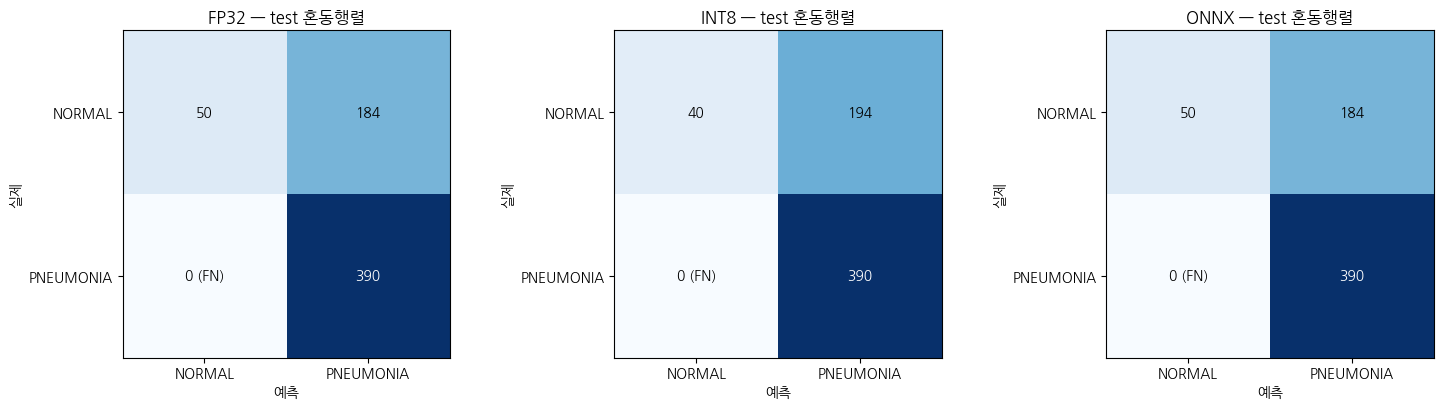

In [ ]:
file_sizes_mb = {
    "FP32": FP32_PATH.stat().st_size / (1024 * 1024),
    "INT8": INT8_PATH.stat().st_size / (1024 * 1024),
    "ONNX": ONNX_PATH.stat().st_size / (1024 * 1024),
}

header = f"{'포맷':<6} {'용량(MB)':>9} {'accuracy':>9} {'Recall(폐렴)':>12} {'FN':>4} {'지연시간(ms)':>13}"
print(header)
for name in ("FP32", "INT8", "ONNX"):
    m = results[name]
    mean_ms, std_ms = latency[name]
    print(
        f"{name:<6} {file_sizes_mb[name]:>9.2f} {m['accuracy']:>9.4f} "
        f"{m['recall']:>12.4f} {m['fn']:>4} {mean_ms:>9.2f} ±{std_ms:.2f}"
    )

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, name in zip(axes, ("FP32", "INT8", "ONNX")):
    plot_confusion_matrix(results[name]["cm"], f"{name} — test 혼동행렬", ax=ax)
fig.tight_layout()
plt.show()

### H-e. 비교 결과 분석

- **FP32 vs ONNX → 수치 등가 변환**: test 624장 예측이 **완전 일치(624/624)** 합니다. 용량도 거의 같습니다.(16.24 → 16.03 MB)  
  즉 ONNX 변환의 가치는 압축이 아니라 **런타임 이식성과 속도**라는 것을 확인 할 수 있습니다.  
  동일 정확도에서 지연시간 20.20 → 9.40 ms 로 **2.15배 단축** 되었습니다.
- **INT8 → 용량·속도 이득과 안전한 방향의 열화**: 용량 **3.64배 압축**(16.24 → 4.47 MB), 지연시간 **1.76배 단축**(20.20 → 11.50 ms) 되었습니다만,  
  대가는 예측 26/624건 변화로 accuracy −1.60%p 하락했습니다.(위양성 증가)  
  변화가 **전부 FP(정상→폐렴) 방향**이라 Recall(폐렴) 1.0, **FN 0이 그대로 유지**되었습니다.(위음성 없음)  
  미션 06 원칙(FN 증가 = 개악) 기준으로 이 양자화는 열화가 아니라 수용 가능한 트레이드오프로 볼 수 있습니다.
- **ONNX가 INT8보다 빠른 이유**: onnxruntime의 그래프 최적화(연산 융합, 메모리 플래닝)가 FP32 그래프에 효과적으로 작동하는 반면,  
  eager PTQ 산출물은 TorchScript 인터프리터 오버헤드를 안고 있습니다.  
  INT8의 확실한 이점은 **용량(저장소·메모리)**이며, 속도 이득은 런타임 최적화 수준에 좌우됨을 보여주는 결과로 볼 수 있습니다.

### H-f. On-Device 배포 관점 결론

- **메모리·저장소 예산**: INT8 4.47 MB는 모바일 앱 번들과 RAM 상주에 부담이 없는 수준이며,  
  FP32/ONNX 16 MB 용량도 배포 가능하나 4배 차이는 초저사양 기기와 다중 모델 시나리오에서 유의미하다고 볼 수 있습니다.
- **지연시간 예산**: 단일 스레드 최악 조건에서 9 ~ 20 ms → X-ray 판독 보조처럼 단건 추론 시나리오에는 충분하다고 봅니다.
  단, 본 측정은 랩톱 x86 기준이므로 모바일 AP에서는 2 ~ 5배 느려질 수 있다고 보고 여유를 잡아야 할 것이라 추정합니다.
- **백엔드 이식성**: 프로젝트의 INT8은 x86 `fbgemm` 기준입니다.  
  ARM 모바일 배포 시 `qnnpack`(PyTorch/ExecuTorch) 또는 XNNPACK 계열로 재양자화 및 재검증이 필요하며,  
  INT8의 상대 이득은 플랫폼별로 달라지게 됩니다.  
  ONNX 경로는 ORT Mobile, NNAPI/CoreML EP 등 가속 백엔드로 확장할 수 있어 **프레임워크 독립성 측면에서 가장 유연**합니다.
- **의료 도메인 원칙**: 이 보정 조건(train 300장 균형 추출)에서는 양자화 후에도 FN 0이 유지되어 INT8 배포가 타당합니다.  
  단 보정 데이터나 모델이 변경될 시에는 **FN 재검증(위음성 증가 여부)이 필수**입니다.
- **종합**: 저장소나 메모리 제약이 큰 초저사양 기기는 INT8,  
  런타임 이식성과 추론 속도가 우선이면 ONNX가 적합합니다.  
  두 경로 모두 기준(FP32) 대비 Recall(폐렴), FN 열화가 없음을 확인했습니다.